In [374]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [360]:
train_data = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/working_data/5s_0.5.csv')
test_data = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/meta_test_data/5s_0.5.csv')

features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_5s_yo_0.5.csv')

with open('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/imb_files/final_hpt_choices.pkl', 'rb') as f:
    final_choices = pickle.load(f)

Get the groups in the test data to make sure that the same experiments are selected as the true label for validating the state-space classifier.

In [361]:
groups = test_data['experiment_id']

features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
features_test = features[features['experiment_id'].isin(groups)]

X_test_3_class = features_test.drop(['experiment_id', 'label'], axis=1)
y_test_3_class = features_test['label']

In [362]:
# Prepare training and testing data
X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']

In [363]:
# Get the tuned model parameters, selected model and imbalanced handling technique
tuned_model_imb_params = final_choices['5s_0.5']
params = tuned_model_imb_params['params']

In [364]:
model = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=int(params['min_samples_split']),
        min_samples_leaf=int(params['min_samples_leaf']),
        max_features=params['max_features'],
        bootstrap=params['bootstrap']
    )

In [365]:
# Apply the sampler
sampler = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

In [366]:
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)

In [367]:
model.fit(X_train_resampled, y_train_encoded)
y_pred = label_encoder.inverse_transform(model.predict(X_test))

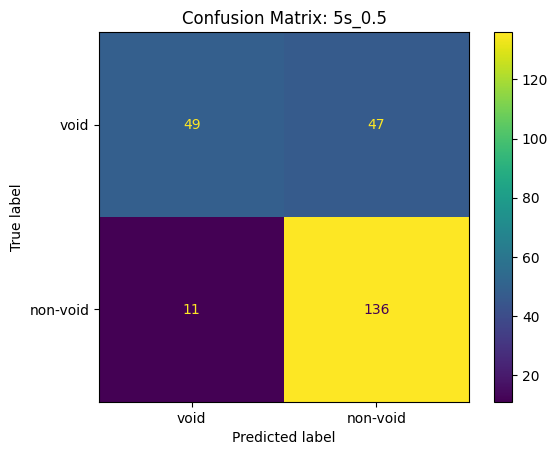

Classification Report: 5s_0.5
              precision    recall  f1-score   support

        void       0.82      0.51      0.63        96
    non-void       0.74      0.93      0.82       147

    accuracy                           0.76       243
   macro avg       0.78      0.72      0.73       243
weighted avg       0.77      0.76      0.75       243

Accuracy: 0.7613168724279835


In [368]:
class_names = ['void', 'non-void']
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_names)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['void', 'non-void'])
cm_display.plot()
plt.title(f'Confusion Matrix: 5s_0.5')
plt.show()
    
    
print(f"Classification Report: 5s_0.5")
print(classification_report(y_test, y_pred, labels=class_names))
print("Accuracy:", accuracy_score(y_test, y_pred))

In [369]:
y_pred_prob = model.predict_proba(X_test)

In [ ]:
y_pred_prob
#Save probabilities


array([[0.61232876, 0.38767124],
       [0.63289482, 0.36710518],
       [0.65374723, 0.34625277],
       [0.43397793, 0.56602207],
       [0.53494821, 0.46505179],
       [0.46597904, 0.53402096],
       [0.1551583 , 0.8448417 ],
       [0.22850101, 0.77149899],
       [0.4989628 , 0.5010372 ],
       [0.46262351, 0.53737649],
       [0.61355672, 0.38644328],
       [0.58045024, 0.41954976],
       [0.68617103, 0.31382897],
       [0.87216864, 0.12783136],
       [0.83395035, 0.16604965],
       [0.61382836, 0.38617164],
       [0.40227844, 0.59772156],
       [0.39845427, 0.60154573],
       [0.36051197, 0.63948803],
       [0.44565348, 0.55434652],
       [0.30491828, 0.69508172],
       [0.23758612, 0.76241388],
       [0.44000672, 0.55999328],
       [0.51314153, 0.48685847],
       [0.3966817 , 0.6033183 ],
       [0.49532421, 0.50467579],
       [0.37681577, 0.62318423],
       [0.35527873, 0.64472127],
       [0.33678589, 0.66321411],
       [0.39434091, 0.60565909],
       [0.

In [372]:
y_pred_prob_df = pd.DataFrame(y_pred_prob, columns=class_names)
y_pred_prob_df['experiment_id'] = test_data['experiment_id'].values
y_pred_prob_df.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/predictions/5s_0.5_probabilities.csv', index=False)

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


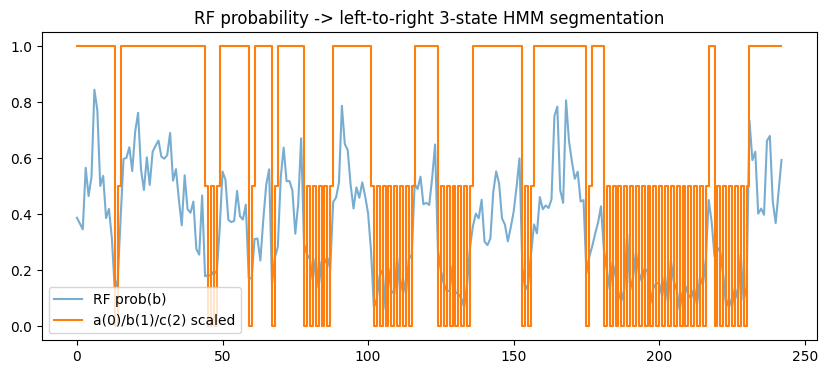

[[0.38767124 2.        ]
 [0.36710518 2.        ]
 [0.34625277 2.        ]
 [0.56602207 2.        ]
 [0.46505179 2.        ]
 [0.53402096 2.        ]
 [0.8448417  2.        ]
 [0.77149899 2.        ]
 [0.5010372  2.        ]
 [0.53737649 2.        ]
 [0.38644328 2.        ]
 [0.41954976 2.        ]
 [0.31382897 2.        ]
 [0.12783136 0.        ]
 [0.16604965 1.        ]
 [0.38617164 2.        ]
 [0.59772156 2.        ]
 [0.60154573 2.        ]
 [0.63948803 2.        ]
 [0.55434652 2.        ]
 [0.69508172 2.        ]
 [0.76241388 2.        ]
 [0.55999328 2.        ]
 [0.48685847 2.        ]
 [0.6033183  2.        ]
 [0.50467579 2.        ]
 [0.62318423 2.        ]
 [0.64472127 2.        ]
 [0.66321411 2.        ]
 [0.60565909 2.        ]]


In [375]:
from hmmlearn import hmm

p = y_pred_prob[:, 1]     # probability for b

# Suppose samples are ordered in time already. If multiple sequences,
# concatenate them but provide lengths to the HMM if fitting multiseq.
obs = p.reshape(-1, 1)

# ---------- build a left-to-right 3-state Gaussian HMM ----------
model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=200, random_state=42)

# Initialize transition matrix to enforce left-to-right flow:
# allow staying in a state or moving to the next, but not backwards.
transmat = np.array([
    [0.90, 0.10, 0.00],  # state 0 -> stay or to state 1
    [0.00, 0.90, 0.10],  # state 1 -> stay or to state 2
    [0.00, 0.00, 1.00]   # state 2 -> absorb (or set 0.90/0.10 if you want moves)
])

# start in state 0 (before activity)
startprob = np.array([1.0, 0.0, 0.0])

# initialize means sensibly (low, mid/high, low-but-different)
# We can set state 1 mean near the mean of high p's, and 0 and 2 near low p ranges
mu_est = np.percentile(p, [10, 85, 40])  # crude heuristic: 10% low, 85% high, 40% mid-low
means_init = np.column_stack([mu_est])   # shape (n_components, n_features)

model.startprob_ = startprob
model.transmat_ = transmat
model.means_ = means_init
model.covars_ = np.tile(np.var(p) * 0.5, (3, 1))  # initial covariances

# Fit the HMM to probability observations (you can pass lengths if multiple sequences)
model.fit(obs)   # if you have multiple sequences, use model.fit(obs, lengths=seq_lengths)

# Decode most likely states
states = model.predict(obs)

# For interpretability, reorder states by their mean observed p
state_means = np.array([obs[states == i].mean() if np.any(states == i) else np.nan for i in range(3)])
order = np.argsort(state_means)   # low -> mid -> high
# Create mapping original->ordered: we want state corresponding to activity to map to label 'b'
# In many cases, the middle/high mean will be the b-state. We'll relabel to a(0), b(1), c(2)
mapping = {orig: new for new, orig in enumerate(order)}
ordered_states = np.vectorize(mapping.get)(states)

# Now ordered_states are labels 0=a, 1=b, 2=c
# Quick plot
plt.figure(figsize=(10,4))
plt.plot(p, label='RF prob(b)', alpha=0.6)
plt.step(range(len(p)), ordered_states/2.0, where='post', label='a(0)/b(1)/c(2) scaled')
plt.legend()
plt.title('RF probability -> left-to-right 3-state HMM segmentation')
plt.show()

# Print small table
print(np.column_stack([p[:30], ordered_states[:30]]))